# Imports


In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import random
import plotly.express as px
import scipy as sp

from scipy import ndimage
from shutil import copyfile
from tensorflow.keras.layers import Conv2D,Add,MaxPooling2D, Dense, BatchNormalization,Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import scipy

# Directorios del Dataset

El dataset de rayos X ya viene organizado en carpetas train, test y val con las subcarpetas NORMAL y PNEUMONIA.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os

source_dir = '/content/drive/MyDrive/X-ray'
dest_dir = 'X-ray'


if os.path.exists(dest_dir):
    shutil.rmtree(dest_dir)


shutil.copytree(source_dir, dest_dir)
print(f"Successfully copied '{source_dir}' to '{dest_dir}'")

Successfully copied '/content/drive/MyDrive/X-ray' to 'X-ray'


In [ ]:
BASE_DIR = 'X-ray'


TRAINING_DIR = os.path.join(BASE_DIR, "train")
VALIDATION_DIR = os.path.join(BASE_DIR, "val")
TEST_DIR = os.path.join(BASE_DIR, "test")

TRAINING_NORMAL = os.path.join(TRAINING_DIR, "NORMAL")
TRAINING_PNEUMONIA = os.path.join(TRAINING_DIR, "PNEUMONIA")

VALIDATION_NORMAL = os.path.join(VALIDATION_DIR, "NORMAL")
VALIDATION_PNEUMONIA = os.path.join(VALIDATION_DIR, "PNEUMONIA")

TEST_NORMAL = os.path.join(TEST_DIR, "NORMAL")
TEST_PNEUMONIA = os.path.join(TEST_DIR, "PNEUMONIA")


INCLUDE_TEST = True

In [ ]:
print(len(os.listdir(TRAINING_NORMAL)))
print(len(os.listdir(TRAINING_PNEUMONIA)))
print(len(os.listdir(VALIDATION_NORMAL)))
print(len(os.listdir(VALIDATION_PNEUMONIA)))
print(len(os.listdir(TEST_NORMAL)))
print(len(os.listdir(TEST_PNEUMONIA)))

1341
3875
8
8
234
390


In [ ]:
class_names = ['Normal', 'Pneumonia']

n_normal = len(os.listdir('X-ray/train/NORMAL'))
n_pneumonia = len(os.listdir('X-ray/train/PNEUMONIA'))
n_images = [n_normal, n_pneumonia]
px.pie(names=class_names, values=n_images)

# Exploración del Dataset

In [ ]:
train_normal = len(os.listdir(TRAINING_NORMAL))
train_pneumonia = len(os.listdir(TRAINING_PNEUMONIA))

val_normal = len(os.listdir(VALIDATION_NORMAL))
val_pneumonia = len(os.listdir(VALIDATION_PNEUMONIA))

test_normal = len(os.listdir(TEST_NORMAL))
test_pneumonia = len(os.listdir(TEST_PNEUMONIA))

total_train = train_normal + train_pneumonia
total_val = val_normal + val_pneumonia
total_test = test_normal + test_pneumonia
total_all = total_train + total_val + total_test


print(f"Training Normal: {train_normal} imágenes")
print(f"Training Pneumonia: {train_pneumonia} imágenes")
print(f"Total Training: {total_train} imágenes ({(total_train/total_all)*100:.2f}%)\n")

print(f"Validation Normal: {val_normal} imágenes")
print(f"Validation Pneumonia: {val_pneumonia} imágenes")
print(f"Total Validation: {total_val} imágenes ({(total_val/total_all)*100:.2f}%)\n")

print(f"Test Normal: {test_normal} imágenes")
print(f"Test Pneumonia: {test_pneumonia} imágenes")
print(f"Total Test: {total_test} imágenes ({(total_test/total_all)*100:.2f}%)\n")

print(f"Total Imágenes: {total_all}")

Training Normal: 1341 imágenes
Training Pneumonia: 3875 imágenes
Total Training: 5216 imágenes (89.07%)

Validation Normal: 8 imágenes
Validation Pneumonia: 8 imágenes
Total Validation: 16 imágenes (0.27%)

Test Normal: 234 imágenes
Test Pneumonia: 390 imágenes
Total Test: 624 imágenes (10.66%)

Total Imágenes: 5856


# Generadores de Datos

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255)

validation_gen = ImageDataGenerator(
    rescale=1./255.)

if INCLUDE_TEST:
    test_gen = ImageDataGenerator(
        rescale=1./255.)

In [ ]:
train_generator = train_gen.flow_from_directory(
    TRAINING_DIR,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary'
)

validation_generator = validation_gen.flow_from_directory(
    VALIDATION_DIR,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary'
)


if INCLUDE_TEST:
    test_generator = test_gen.flow_from_directory(
        TEST_DIR,
        target_size=(150, 150),
        batch_size=64,
        class_mode='binary'
    )

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


# Visualización de Imágenes

In [ ]:
def plot_data(generator, n_images):

    i = 1

    images, labels = next(generator)

    labels = labels.astype('int32')

    plt.figure(figsize=(14, 15))

    for image, label in zip(images, labels):
        plt.subplot(4, 3, i)
        plt.imshow(image)
        plt.title(class_names[label])
        plt.axis('off')
        i += 1
        if i == n_images:
            break

    plt.show()

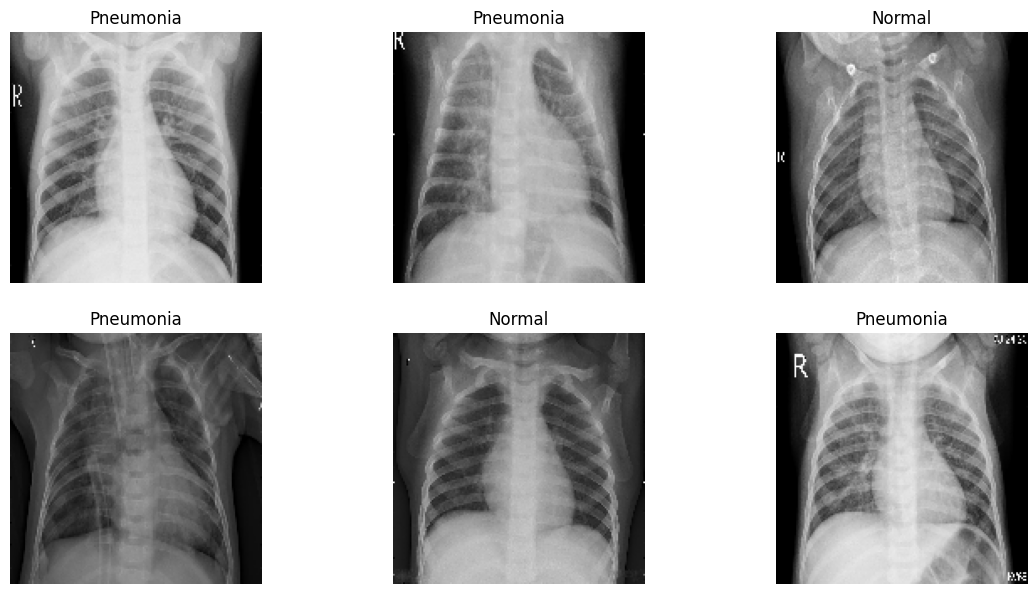

In [ ]:
plot_data(train_generator,7)

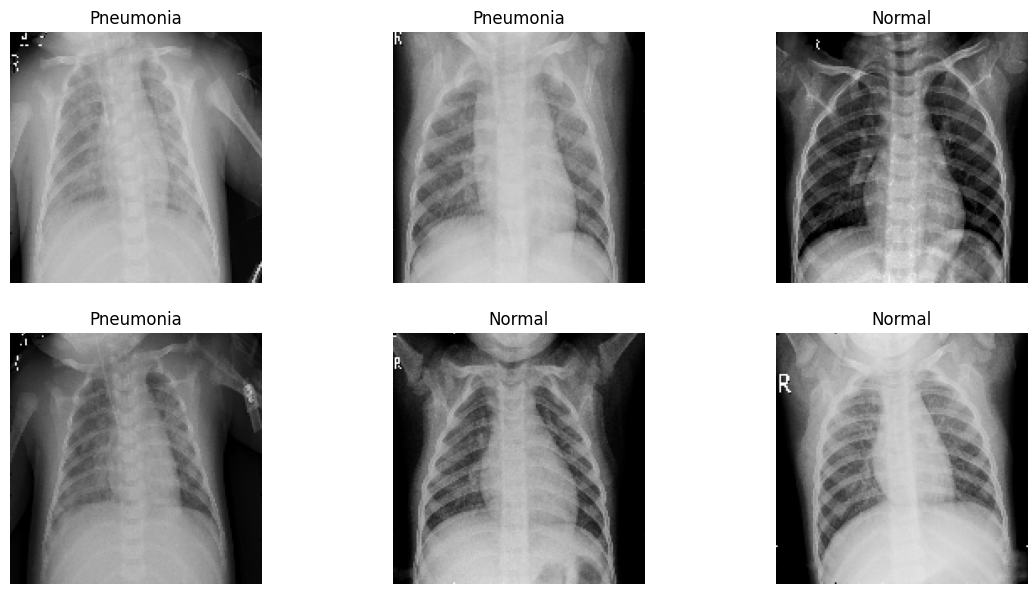

In [ ]:
plot_data(validation_generator,7)

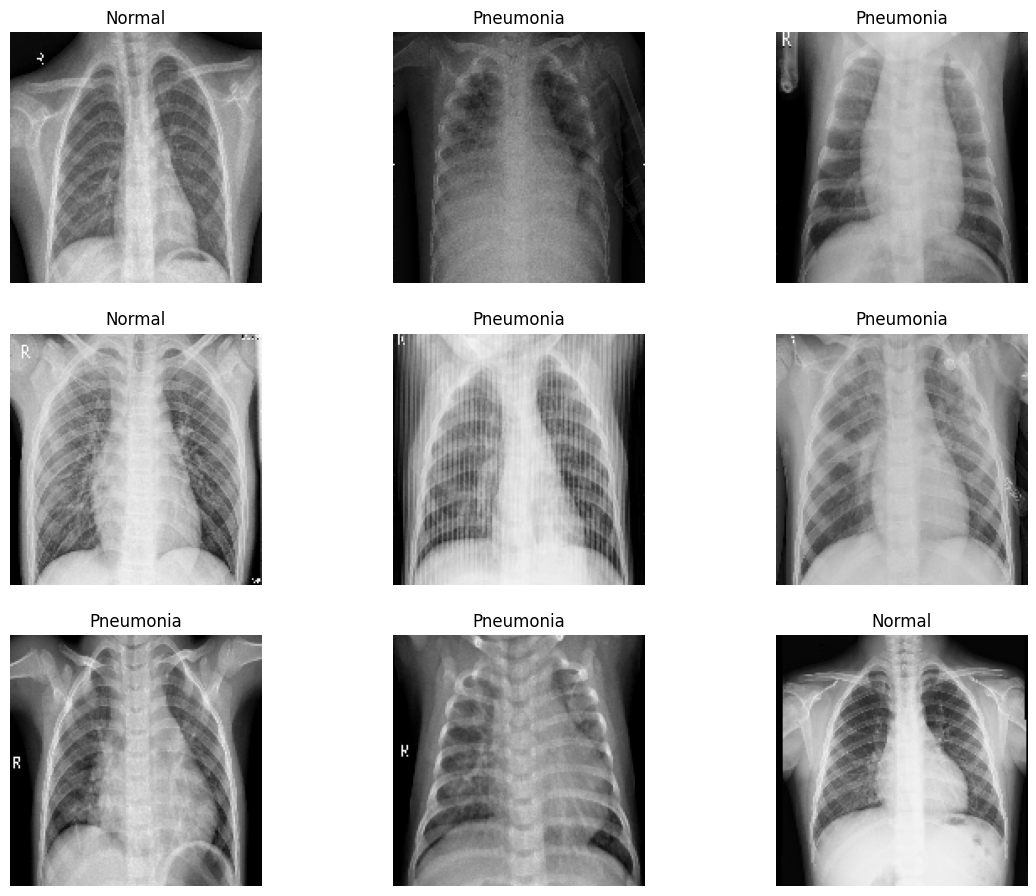

In [ ]:
if INCLUDE_TEST:
    plot_data(test_generator, 10)

# Construcción del Modelo

In [ ]:

inputs = tf.keras.layers.Input(shape=(150,150,3))
x = tf.keras.layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(256, (3,3), activation='relu')(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = Dense(1024, activation='relu')(x)

x = tf.keras.layers.Dense(2, activation='softmax')(x)

model = Model(inputs=inputs, outputs=x)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0005),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

# Entrenamiento del Modelo

In [ ]:

r = model.fit(
        train_generator,
        epochs=15,
        validation_data=validation_generator
)

Epoch 1/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 76s 724ms/step - accuracy: 0.7368 - loss: 0.5851 - val_accuracy: 0.5000 - val_loss: 1.0217
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 49s 597ms/step - accuracy: 0.7429 - loss: 0.5720 - val_accuracy: 0.5000 - val_loss: 0.9302
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 48s 588ms/step - accuracy: 0.7391 - loss: 0.5461 - val_accuracy: 0.5000 - val_loss: 0.9862
Epoch 4/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 50s 610ms/step - accuracy: 0.7799 - loss: 0.4684 - val_accuracy: 0.7500 - val_loss: 0.5427
Epoch 5/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 49s 597ms/step - accuracy: 0.7987 - loss: 0.4053 - val_accuracy: 0.6250 - val_loss: 1.2245
Epoch 6/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 50s 612ms/step - accuracy: 0.8200 - loss: 0.3706 - val_accuracy: 0.6250 - val_loss: 0.8156
Epoch 7/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 49s 600ms/step - accuracy: 0.8374 - loss: 0.3353 - val_accuracy: 0.6250 - val_loss: 1.1501
Epoch 8/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 50s 607ms/step - accuracy: 0.8510 - loss: 0.3179 - val_accu

# Evaluación en Test Set

In [ ]:
if INCLUDE_TEST:
    model.evaluate(test_generator)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 624ms/step - accuracy: 0.7452 - loss: 0.6568


# Predicciones y Visualización

In [ ]:
def plot_prediction(generator, n_images):

    i = 1

    images, labels = next(generator)

    preds = model.predict(images)

    predictions = np.argmax(preds, axis=1)

    labels = labels.astype('int32')

    plt.figure(figsize=(14, 15))

    for image, label in zip(images, labels):
        plt.subplot(4, 3, i)
        plt.imshow(image)

        if predictions[i-1] == labels[i-1]:
            title_obj = plt.title(class_names[label])
            plt.setp(title_obj, color='g')
            plt.axis('off')
        else:
            title_obj = plt.title(class_names[label])
            plt.setp(title_obj, color='r')
            plt.axis('off')

        i += 1

        if i > n_images:
            break

    plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step


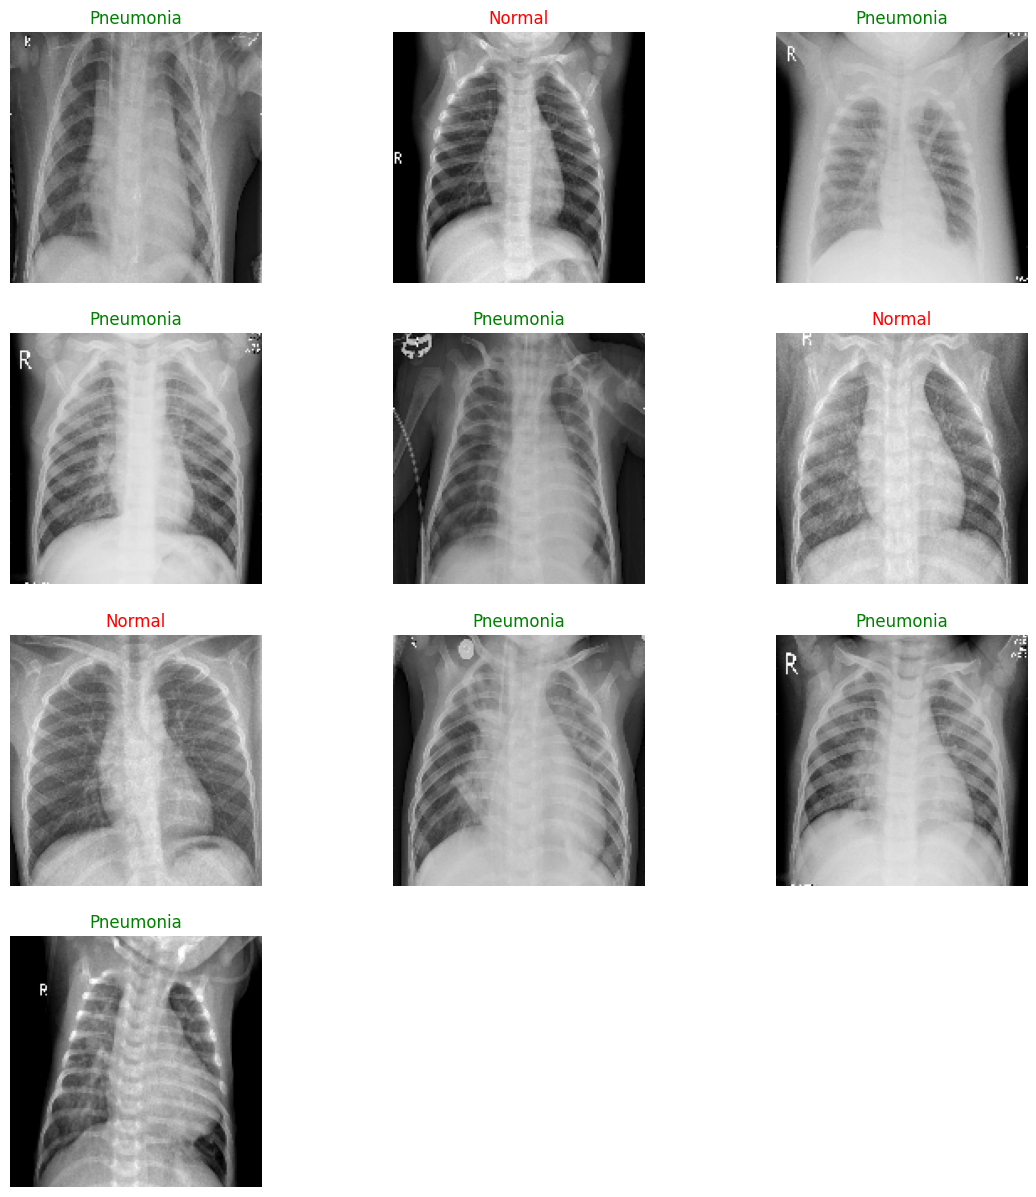

In [ ]:
if INCLUDE_TEST:
    plot_prediction(test_generator, 10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step


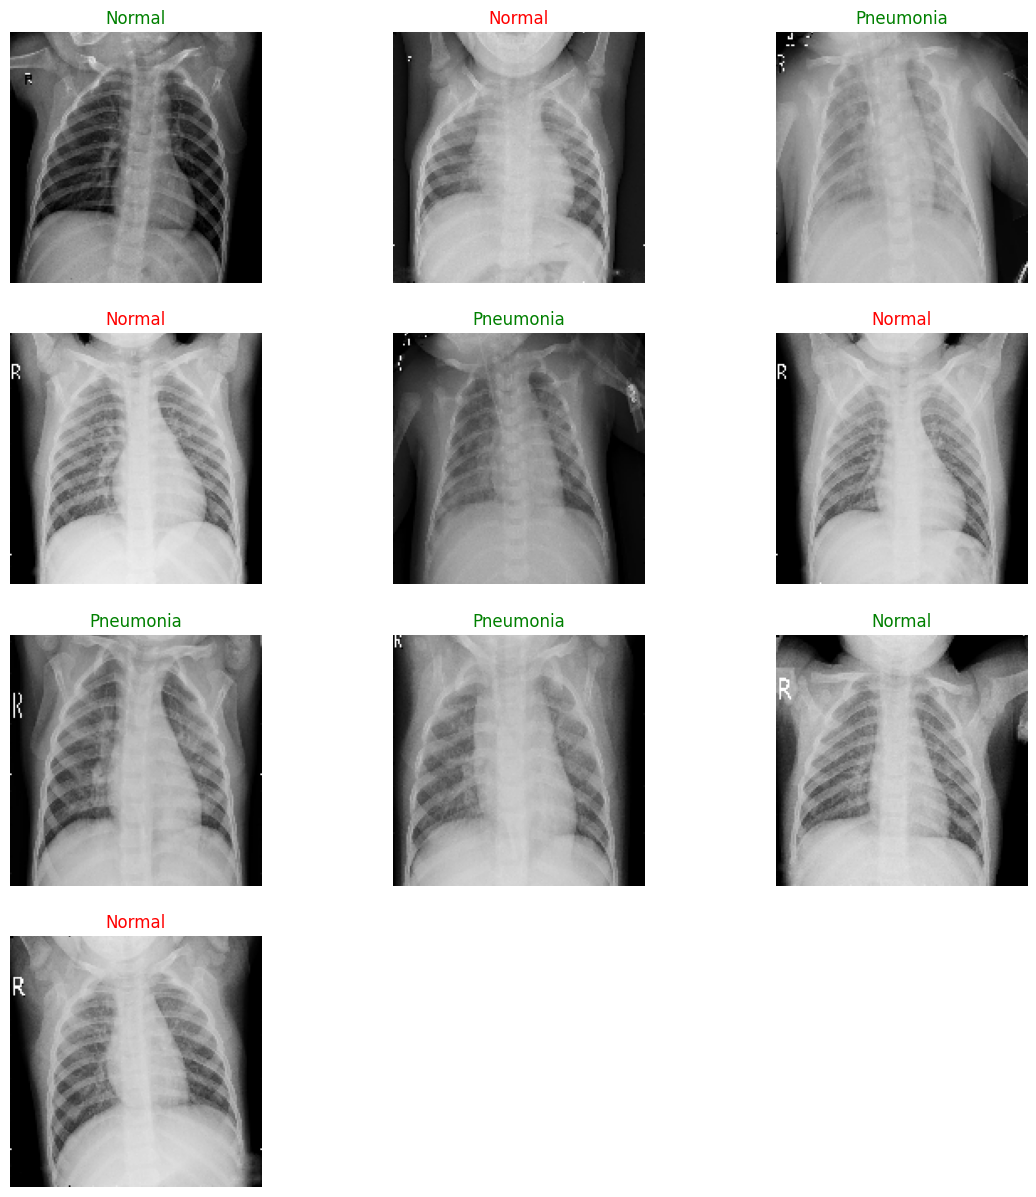

In [ ]:
plot_prediction(validation_generator, 10)

# Mapas de Activación de Clase (CAM)

In [ ]:
gp_weights_dense_intermediate = model.get_layer('dense').get_weights()[0]
gp_weights_dense_final = model.get_layer('dense_1').get_weights()[0]

activation_model = Model(model.inputs, outputs=(model.get_layer('conv2d_5').output, model.get_layer('dense_1').output))

In [ ]:
images, _ = next(test_generator)
features, results = activation_model.predict(images)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step 


In [ ]:
def show_cam(image_index, features, results):

    features_for_img = features[image_index,:,:,:]

    prediction = np.argmax(results[image_index])

    effective_cam_weights = np.dot(gp_weights_dense_intermediate, gp_weights_dense_final[:, prediction])

    class_activation_features = sp.ndimage.zoom(features_for_img, (150/30, 150/30, 1), order=2)

    cam_output  = np.dot(class_activation_features, effective_cam_weights)

    print('Predicted Class = ' + str(class_names[prediction]) + ', Probability = ' + str(results[image_index][prediction]))

    plt.imshow(images[image_index])

    if results[image_index][prediction] > 0.95:
        cmap_str = 'Greens'
    else:
        cmap_str = 'Blues'

    plt.imshow(cam_output, cmap=cmap_str, alpha=0.5)

    plt.show()

In [ ]:
def show_maps(desired_class, num_maps):

    counter = 0
    for i in range(0, len(features)):
        if counter == num_maps:
            break

        if np.argmax(results[i]) == desired_class:
            counter += 1
            show_cam(i, features, results)

Predicted Class = Pneumonia, Probability = 0.9986823


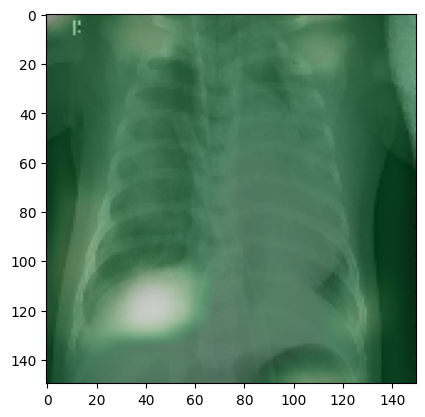

Predicted Class = Pneumonia, Probability = 0.99871755


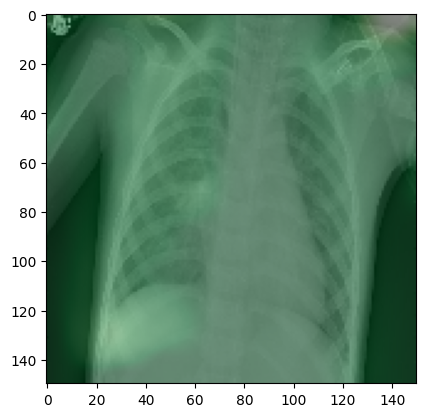

Predicted Class = Pneumonia, Probability = 0.9990395


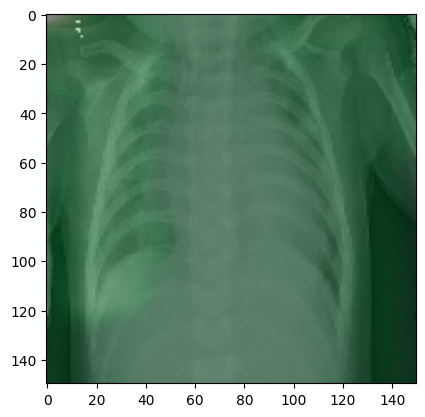

Predicted Class = Pneumonia, Probability = 0.99640995


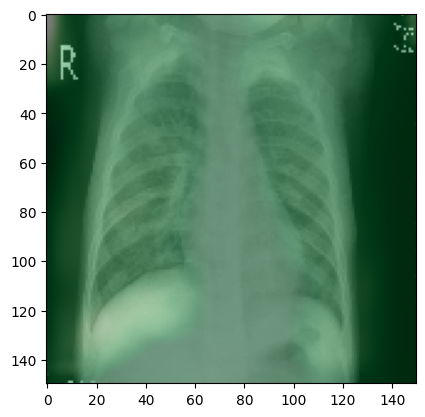

Predicted Class = Pneumonia, Probability = 0.96068764


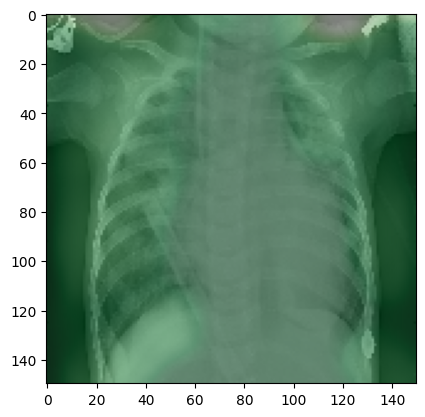

In [ ]:
show_maps(desired_class=1, num_maps=5)

Predicted Class = Normal, Probability = 0.8651703


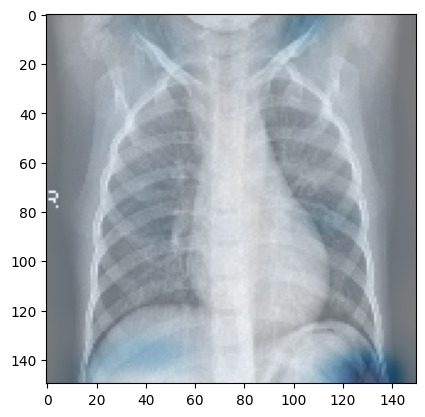

Predicted Class = Normal, Probability = 0.5812768


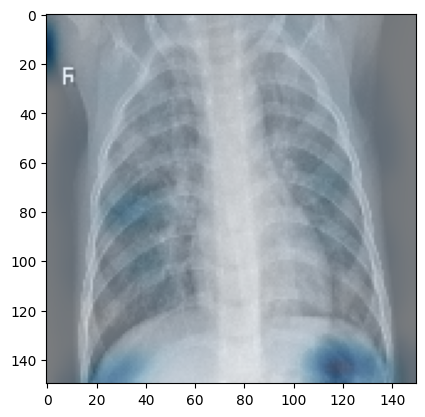

Predicted Class = Normal, Probability = 0.62747175


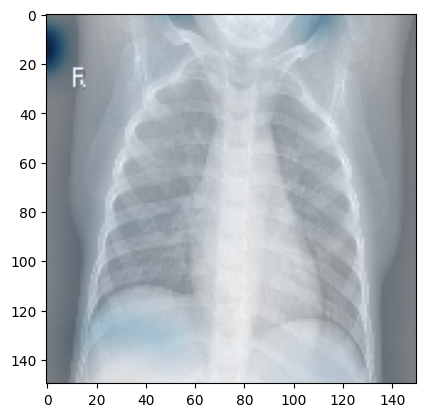

Predicted Class = Normal, Probability = 0.7949792


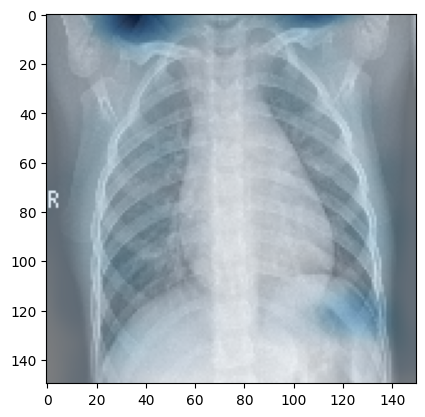

Predicted Class = Normal, Probability = 0.77198213


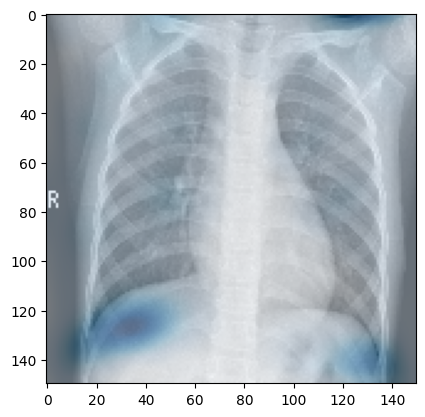

In [ ]:
show_maps(desired_class=0, num_maps=5)

# Análisis de Resultados

In [ ]:
results = pd.DataFrame(r.history)
results.tail()

,accuracy,loss,val_accuracy,val_loss
10,0.858129,0.307610,0.7500,0.434751
11,0.857170,0.299555,0.6250,1.028642
12,0.866373,0.284881,0.7500,0.423696
13,0.868673,0.283287,0.6875,0.825933
14,0.880368,0.266252,0.7500,0.721305


In [ ]:
fig = px.line(results,y=[results['accuracy'],results['val_accuracy']],template="seaborn",color_discrete_sequence=['#fad25a','red'])
fig.update_layout(
    title_font_color="#fad25a",
    xaxis=dict(color="#fad25a",title='Epochs'),
    yaxis=dict(color="#fad25a")
 )
fig.show()

In [ ]:
fig = px.line(results,y=[results['loss'],results['val_loss']],template="seaborn",color_discrete_sequence=['#fad25a','red'])
fig.update_layout(
    title_font_color="#fad25a",
    xaxis=dict(color="#fad25a",title='Epochs'),
    yaxis=dict(color="#fad25a")
 )
fig.show()

# Data Augmentation

In [40]:
train_gen_aug = ImageDataGenerator(
        rescale=1./255,fill_mode='nearest',horizontal_flip=True,
        rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
)


validation_gen_aug =  ImageDataGenerator(
        rescale=1./255.)

In [41]:
train_generator = train_gen_aug.flow_from_directory(
        TRAINING_DIR,
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')
validation_generator = validation_gen_aug.flow_from_directory(
        VALIDATION_DIR,
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [42]:
inputs = tf.keras.layers.Input(shape=(150,150,3))
x =  tf.keras.layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(256, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(1024, activation='relu')(x)
x = tf.keras.layers.Dense(2, activation='softmax')(x)

model_aug = Model(inputs=inputs, outputs=x)

In [43]:
model_aug.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0005),
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [44]:
r = model_aug.fit(
        train_generator,
        epochs=15,
        validation_data=validation_generator)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 485ms/step - accuracy: 0.7389 - loss: 0.5899 - val_accuracy: 0.5000 - val_loss: 0.6403
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 478ms/step - accuracy: 0.7467 - loss: 0.4836 - val_accuracy: 0.5000 - val_loss: 0.7026
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 469ms/step - accuracy: 0.7671 - loss: 0.4406 - val_accuracy: 0.7500 - val_loss: 0.5578
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 479ms/step - accuracy: 0.8213 - loss: 0.3621 - val_accuracy: 0.6875 - val_loss: 0.7227
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 77s 472ms/step - accuracy: 0.8712 - loss: 0.2895 - val_accuracy: 0.6875 - val_loss: 0.5132
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 479ms/step - accuracy: 0.8857 - loss: 0.2583 - val_accuracy: 0.7500 - val_loss: 0.4885
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 474ms/step - accuracy: 0.8976 - loss: 0.2350 - val_accuracy: 0.7500 - val_loss: 0.7032
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 477ms/step - accuracy: 0.9070 - loss: 0

In [45]:
if INCLUDE_TEST:
    model_aug.evaluate(test_generator)

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 430ms/step - accuracy: 0.8237 - loss: 0.4662


In [46]:
results = pd.DataFrame(r.history)
results.tail()

,accuracy,loss,val_accuracy,val_loss
10,0.933666,0.171856,0.6875,0.983757
11,0.939801,0.158179,0.5625,1.553515
12,0.937692,0.156281,0.7500,0.519963
13,0.940376,0.150688,0.7500,0.565534
14,0.943443,0.140430,0.8125,0.392070


In [47]:
fig = px.line(results,y=[results['accuracy'],results['val_accuracy']],template="seaborn",color_discrete_sequence=['#fad25a','red'])
fig.update_layout(
    title_font_color="#fad25a",
    xaxis=dict(color="#fad25a",title='Epochs'),
    yaxis=dict(color="#fad25a")
 )
fig.show()

In [48]:
fig = px.line(results,y=[results['loss'],results['val_loss']],template="seaborn",color_discrete_sequence=['#fad25a','red'])
fig.update_layout(
    title_font_color="#fad25a",
    xaxis=dict(color="#fad25a",title='Epochs'),
    yaxis=dict(color="#fad25a")
 )
fig.show()